In [1]:
%load_ext autoreload
%autoreload 2

# B6 (partie 2) — Auto-encodeur & détection d'anomalies

Reprend les jeux prétraités en [partie 1](b6_deep_learning_donnees.md) (`screw/*.bin.gz`) pour concevoir,
entraîner et évaluer un auto-encodeur convolutionnel de détection d'anomalies.

In [2]:
import gzip
from pathlib import Path

import numpy as np

DATA_DIR = Path('screw')
IMG_SIZE = 128


def load_bin_gz(path, img_size=IMG_SIZE):
    with gzip.open(path, 'rb') as f:
        data = np.frombuffer(f.read(), dtype='float32')
    return data.reshape(-1, img_size, img_size, 1)


X_train_norm = load_bin_gz(DATA_DIR / 'train_norm.bin.gz')
test_good_norm = load_bin_gz(DATA_DIR / 'test_good_norm.bin.gz')
test_defects_norm_stacked = load_bin_gz(DATA_DIR / 'test_defects_norm.bin.gz')

print('Train (normé)  :', X_train_norm.shape, X_train_norm.dtype)
print('Test saines    :', test_good_norm.shape)
print('Test défauts   :', test_defects_norm_stacked.shape)

Train (normé)  : (256, 128, 128, 1) float32
Test saines    : (41, 128, 128, 1)
Test défauts   : (119, 128, 128, 1)


Conception de l'auto-encodeur

In [3]:
from tensorflow import keras
from tensorflow.keras import layers

INPUT_SHAPE = X_train_norm.shape[1:]  # (128, 128, 1)

inputs = keras.Input(shape=INPUT_SHAPE, name='image')

# Encodeur : 3 convolutions stridées, le nombre de filtres se resserre pour forcer un vrai goulot
x = layers.Conv2D(32, 3, strides=2, padding='same', activation='relu')(inputs)  # 64x64x32
x = layers.Conv2D(64, 3, strides=2, padding='same', activation='relu')(x)       # 32x32x64
latent = layers.Conv2D(8, 3, strides=2, padding='same', activation='relu')(x)   # 16x16x8 (goulot)

# Décodeur : 3 déconvolutions symétriques, sortie sigmoid dans [0, 1].
# Noyau=4 (multiple du stride=2) plutôt que 3, pour éviter l'artefact de damier
# ("checkerboard") typique des Conv2DTranspose quand noyau et stride ne s'accordent pas.
x = layers.Conv2DTranspose(64, 4, strides=2, padding='same', activation='relu')(latent)  # 32x32x64
x = layers.Conv2DTranspose(32, 4, strides=2, padding='same', activation='relu')(x)        # 64x64x32
outputs = layers.Conv2DTranspose(1, 4, strides=2, padding='same', activation='sigmoid')(x)  # 128x128x1

autoencoder = keras.Model(inputs, outputs, name='autoencodeur_screw')
autoencoder.summary()

Model: "autoencodeur_screw"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image (InputLayer)              │ (None, 128, 128, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 8)      │         4,616 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 32, 32, 64)     │         8,256 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 64, 64, 32)     │        32,800 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 128, 128, 1)    │           513 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 65,001 (253.91 KB)

 Trainable params: 65,001 (253.91 KB)

 Non-trainable params: 0 (0.00 B)

In [4]:
input_size = np.prod(INPUT_SHAPE)
latent_size = np.prod(latent.shape[1:])
ratio = latent_size / input_size

print(f'Taille entrée       : {input_size} valeurs {INPUT_SHAPE}')
print(f'Taille goulot       : {latent_size} valeurs {tuple(latent.shape[1:])}')
print(f'Ratio goulot/entrée : {ratio:.3f}  (compression ×{1 / ratio:.1f})')

Taille entrée       : 16384 valeurs (128, 128, 1)
Taille goulot       : 2048 valeurs (16, 16, 8)
Ratio goulot/entrée : 0.125  (compression ×8.0)


**Commentaire.** Le modèle compte **65 001 paramètres** (tous entraînables), essentiellement dans les
6 couches de convolution/déconvolution — pas de couche dense, donc pas d'explosion de paramètres malgré
la taille des images (128×128). Le décodeur utilise un noyau de taille **4** (multiple du stride 2, au lieu
de 3) pour éviter l'artefact de damier ("checkerboard") typique des `Conv2DTranspose`, ce qui explique le
léger surplus de paramètres par rapport à un noyau 3×3.

Le **goulot d'étranglement** est la sortie de la 3ᵉ convolution : `16×16×8 = 2048` valeurs, contre
`128×128×1 = 16384` valeurs en entrée → **ratio de 0.125** (compression ×8). Ce ratio est volontairement
resserré via le nombre de filtres (32 → 64 → **8**, et non croissant jusqu'au bout) : avec un goulot proche
de la taille d'entrée, le modèle pourrait apprendre une quasi-identité et reconstruire aussi bien les
défauts que les pièces saines, ce qui ferait disparaître le signal d'anomalie recherché.

# Étape 2

Entrainement du model, on entraine (enregistrement via MLFlow) un model

In [5]:
import mlflow
import tensorflow as tf

mlflow.set_tracking_uri('sqlite:///../mlflow.db')
mlflow.set_experiment('b6_deep_learning_autoencodeur')


def ssim_loss(y_true, y_pred):
    return 1 - tf.reduce_mean(tf.image.ssim(y_true, y_pred, max_val=1.0))


EPOCHS = 30
BATCH_SIZE = 16

autoencoder.compile(optimizer='adam', loss=ssim_loss)

with mlflow.start_run(run_name='autoencoder_conv_screw_ssim'):
    mlflow.log_params({
        'epochs': EPOCHS,
        'batch_size': BATCH_SIZE,
        'optimizer': 'adam',
        'loss': 'ssim',
        'decoder_kernel_size': 4,
        'latent_shape': str(tuple(latent.shape[1:])),
        'compression_ratio': round(float(ratio), 4),
    })

    history = autoencoder.fit(
        X_train_norm, X_train_norm,
        validation_split=0.2,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        shuffle=True,
        verbose=2,
    )

    for epoch, (loss, val_loss) in enumerate(zip(history.history['loss'], history.history['val_loss'])):
        mlflow.log_metrics({'loss': loss, 'val_loss': val_loss}, step=epoch)

Epoch 1/30


13/13 - 5s - 421ms/step - loss: 0.2885 - val_loss: 0.2690


Epoch 2/30


13/13 - 5s - 349ms/step - loss: 0.2423 - val_loss: 0.2199


Epoch 3/30


...

13/13 - 8s - 593ms/step - loss: 0.0545 - val_loss: 0.0540


Epoch 29/30


13/13 - 7s - 505ms/step - loss: 0.0541 - val_loss: 0.0536


Epoch 30/30


13/13 - 6s - 479ms/step - loss: 0.0534 - val_loss: 0.0532


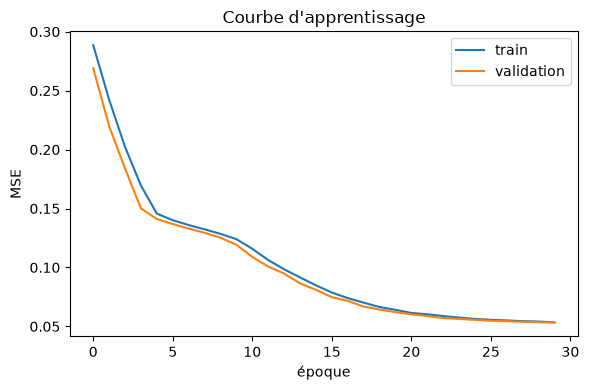

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='validation')
plt.xlabel('époque')
plt.ylabel('MSE')
plt.title("Courbe d'apprentissage")
plt.legend()
plt.tight_layout()
plt.show()

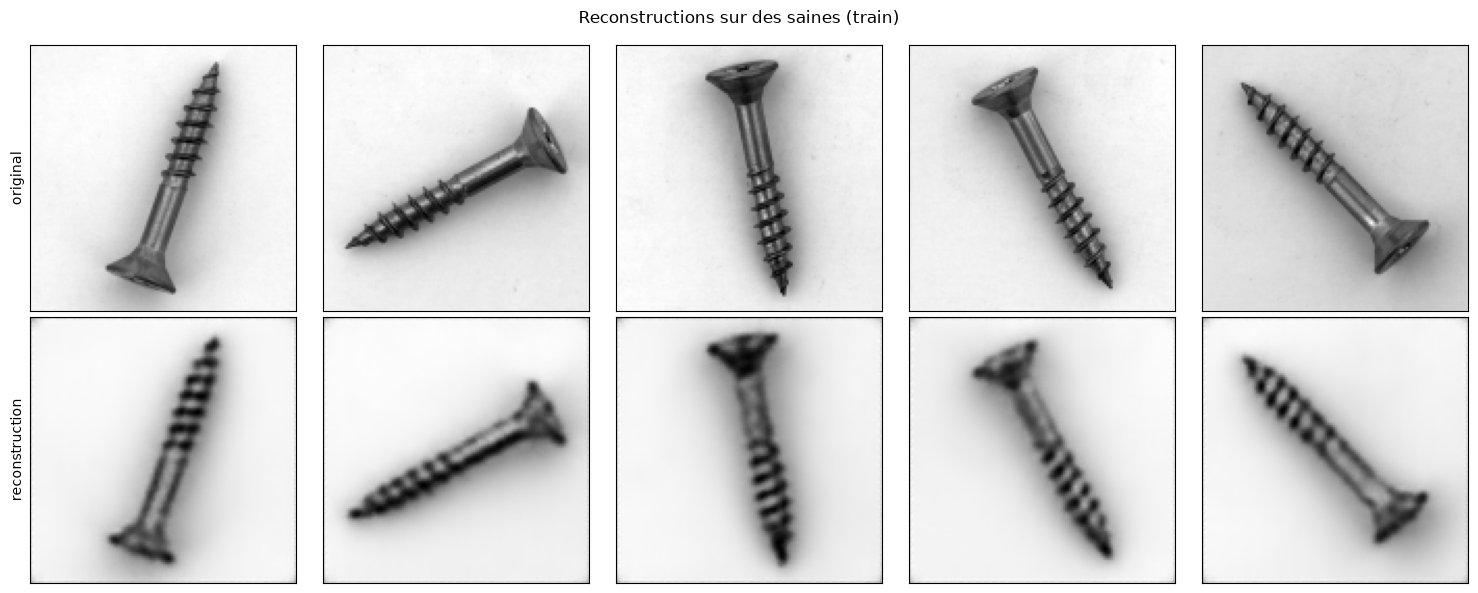

In [7]:
n_examples = 5
reconstructions = autoencoder.predict(X_train_norm[:n_examples], verbose=0)

fig, axes = plt.subplots(2, n_examples, figsize=(3 * n_examples, 6))
for i in range(n_examples):
    axes[0, i].imshow(X_train_norm[i, ..., 0], cmap='gray')
    axes[1, i].imshow(reconstructions[i, ..., 0], cmap='gray')

axes[0, 0].set_ylabel('original')
axes[1, 0].set_ylabel('reconstruction')
for ax in axes.ravel():
    ax.set_xticks([])
    ax.set_yticks([])

fig.suptitle('Reconstructions sur des saines (train)')
fig.tight_layout()
plt.show()